<a href="https://colab.research.google.com/github/irfan060606/Practical-Statistics-for-Data-Scientists/blob/main/Chapter_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3 — Statistical Experiments and Significance Testing

**Practical Statistics for Data Scientists — Peter Bruce, Andrew Bruce, Peter Gedeck**

Notebook ini merupakan reproduksi dan *theoretical deep-dive* untuk Bab 3. Materi mengikuti urutan utama buku: eksperimen A/B, hipotesis, resampling/permutation test, statistical significance dan p-values, t-tests, multiple testing, degrees of freedom, ANOVA, chi-square test, multi-arm bandit, serta power dan sample size.

> **Catatan:** kode ditulis ulang dengan struktur yang lebih mandiri agar notebook dapat dipelajari dan dijalankan sebagai satu kesatuan.

## Tujuan Pembelajaran

Setelah menyelesaikan notebook ini, kita dapat:

1. memahami tujuan eksperimen A/B dan perbandingan dua kelompok;
2. membedakan null hypothesis dan alternative hypothesis;
3. memahami permutation test sebagai pendekatan resampling untuk menguji hipotesis;
4. menjelaskan p-value, alpha, Type I error, dan Type II error;
5. menggunakan t-test sebagai pendekatan parametrik untuk membandingkan rata-rata;
6. memahami masalah multiple testing dan degrees of freedom;
7. memahami ANOVA dan F-statistic untuk beberapa kelompok;
8. memahami chi-square test untuk data berbentuk hitungan/kategori;
9. memahami ide multi-arm bandit;
10. menghubungkan power dengan kebutuhan sample size.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

pd.set_option("display.precision", 4)

DATA_URL = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/"
rng = np.random.default_rng(42)

## 1. A/B Testing

A/B testing membandingkan dua perlakuan atau versi, misalnya **Page A** dan **Page B**. Dalam contoh buku, variabel yang diamati adalah waktu kunjungan (*session time*).

Pertanyaan statistiknya bukan hanya “mana yang memiliki rata-rata lebih besar?”, tetapi apakah perbedaan yang diamati masih dapat dijelaskan oleh variasi acak.

In [2]:
web_page_data = pd.read_csv(DATA_URL + "web_page_data.csv")
web_page_data.head()

,Page,Time
0,Page A,0.21
1,Page B,2.53
2,Page A,0.35
3,Page B,0.71
4,Page A,0.67


In [3]:
summary = (
    web_page_data.groupby("Page")["Time"]
    .agg(["count", "mean", "std"])
    .rename(columns={"count": "n", "mean": "mean_time", "std": "std_time"})
)

summary

,n,mean_time,std_time
Page,,,
Page A,21,1.2633,0.8846
Page B,15,1.6200,1.0114


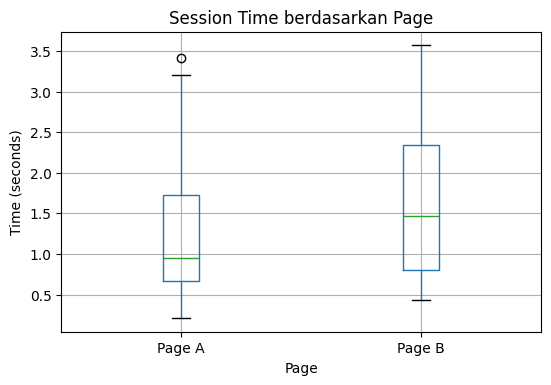

In [4]:
ax = web_page_data.boxplot(column="Time", by="Page", figsize=(6, 4))
ax.set_title("Session Time berdasarkan Page")
ax.set_xlabel("Page")
ax.set_ylabel("Time (seconds)")
plt.suptitle("")
plt.show()

### Interpretasi awal

Perbedaan rata-rata merupakan **observed effect**. Pada tahap ini kita belum menyatakan bahwa perbedaan tersebut benar-benar berasal dari perlakuan. Kita perlu membandingkannya dengan variasi yang mungkin muncul jika perlakuan sebenarnya tidak memberikan perbedaan.

## 2. Hypothesis Tests

Uji hipotesis menggunakan dua gagasan utama:

- **Null hypothesis (H₀):** tidak ada perbedaan/efek yang ingin dibuktikan.
- **Alternative hypothesis (H₁):** terdapat perbedaan/efek.

Dalam A/B testing, H₀ dapat dipahami sebagai asumsi bahwa hasil Page A dan Page B berasal dari kondisi yang sama sehingga perbedaan yang terlihat dapat muncul karena random variation.

Uji hipotesis membutuhkan **test statistic**, yaitu ukuran numerik yang menggambarkan efek yang sedang diuji.

## 3. Resampling — Permutation Test

Buku menjelaskan permutation test sebagai prosedur resampling untuk menguji hipotesis.

Ide dasarnya:

1. gabungkan observasi dari kelompok A dan B;
2. acak data gabungan;
3. bagi kembali menjadi kelompok dengan ukuran seperti semula;
4. hitung kembali statistik, misalnya selisih mean;
5. ulangi berkali-kali untuk membentuk **permutation distribution**;
6. bandingkan observed difference dengan distribusi hasil permutasi.

Jika observed difference berada jauh di luar variasi yang umum dihasilkan permutasi, maka data memberikan lebih banyak bukti terhadap adanya perbedaan daripada yang diharapkan dari random variation saja.

In [5]:
def permutation_mean_difference(x_a, x_b, repetitions=5000, seed=42):
    local_rng = np.random.default_rng(seed)
    pooled = np.concatenate([x_a, x_b])
    n_a = len(x_a)

    observed = x_a.mean() - x_b.mean()
    simulated = np.empty(repetitions)

    for i in range(repetitions):
        shuffled = local_rng.permutation(pooled)
        simulated[i] = shuffled[:n_a].mean() - shuffled[n_a:].mean()

    return observed, simulated


time_a = web_page_data.loc[web_page_data["Page"] == "Page A", "Time"].to_numpy()
time_b = web_page_data.loc[web_page_data["Page"] == "Page B", "Time"].to_numpy()

observed_diff, permutation_diffs = permutation_mean_difference(
    time_a, time_b, repetitions=5000, seed=42
)

print(f"Observed difference (A - B): {observed_diff:.3f} seconds")

Observed difference (A - B): -0.357 seconds


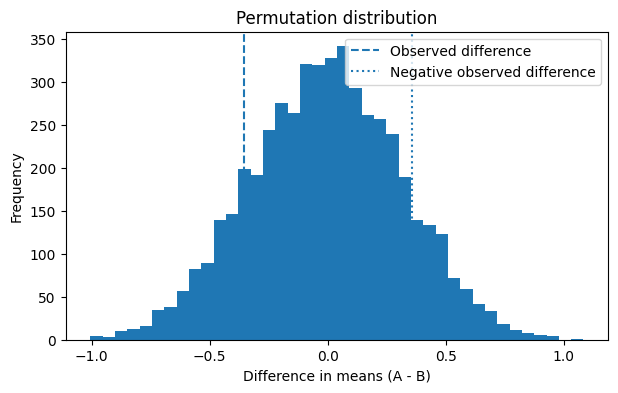

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(permutation_diffs, bins=40)
ax.axvline(observed_diff, linestyle="--", label="Observed difference")
ax.axvline(-observed_diff, linestyle=":", label="Negative observed difference")
ax.set_xlabel("Difference in means (A - B)")
ax.set_ylabel("Frequency")
ax.set_title("Permutation distribution")
ax.legend()
plt.show()

## 4. Statistical Significance dan p-Values

**p-value** mengukur seberapa sering statistik yang sama ekstremnya dengan hasil observasi muncul dalam reference distribution yang dibentuk berdasarkan null hypothesis.

Untuk uji dua arah pada permutation test, kita dapat menghitung proporsi hasil permutasi yang nilai absolutnya setidaknya sebesar nilai absolut observed difference.

**Alpha (α)** adalah significance level yang ditentukan sebelum pengujian. Nilai yang umum digunakan adalah 0.05.

In [7]:
alpha = 0.05
p_value_perm = np.mean(np.abs(permutation_diffs) >= abs(observed_diff))

print(f"Permutation p-value (two-sided): {p_value_perm:.4f}")
print(f"Alpha: {alpha:.2f}")

Permutation p-value (two-sided): 0.2708
Alpha: 0.05


### Type I dan Type II Error

- **Type I error:** menolak H₀ ketika H₀ sebenarnya benar.
- **Type II error:** gagal menolak H₀ ketika alternative yang relevan sebenarnya benar.

P-value bukan probabilitas bahwa H₀ benar. P-value berbicara tentang seberapa kompatibel data yang diamati dengan reference distribution di bawah H₀.

## 5. t-Tests

t-test merupakan pendekatan yang umum digunakan untuk menguji perbedaan rata-rata. Buku membahasnya sebagai pendekatan parametrik yang dapat menjadi aproksimasi terhadap distribusi hasil permutation test.

Untuk dua kelompok numerik, Python menyediakan `scipy.stats.ttest_ind`. Di sini digunakan **Welch's t-test** (`equal_var=False`), yang tidak mengharuskan kedua kelompok memiliki varians yang sama.

In [8]:
welch_result = stats.ttest_ind(
    time_a,
    time_b,
    equal_var=False
)

print(f"t-statistic : {welch_result.statistic:.4f}")
print(f"two-sided p-value : {welch_result.pvalue:.4f}")

t-statistic : -1.0983
two-sided p-value : 0.2815


## 6. Multiple Testing

Ketika banyak hipotesis diuji sekaligus, peluang mendapatkan hasil yang tampak signifikan hanya karena kebetulan meningkat.

Salah satu pendekatan sederhana adalah **Bonferroni correction**:

`adjusted alpha = alpha / jumlah pengujian`

Ini menggambarkan mengapa jumlah pengujian perlu diperhatikan ketika banyak perbandingan dilakukan.

In [9]:
alpha_awal = 0.05
jumlah_uji = 20
alpha_bonferroni = alpha_awal / jumlah_uji

print(f"Alpha awal      : {alpha_awal}")
print(f"Jumlah pengujian: {jumlah_uji}")
print(f"Adjusted alpha  : {alpha_bonferroni:.4f}")

Alpha awal      : 0.05
Jumlah pengujian: 20
Adjusted alpha  : 0.0025


## 7. Degrees of Freedom

**Degrees of freedom (df)** menunjukkan jumlah nilai yang secara efektif masih dapat berubah setelah sejumlah batasan atau parameter telah ditentukan.

Dalam beberapa prosedur statistik, bentuk reference distribution bergantung pada degrees of freedom. Pada Welch's t-test, misalnya, df disesuaikan dengan ukuran dan varians kedua kelompok.

## 8. ANOVA

**Analysis of Variance (ANOVA)** digunakan ketika terdapat lebih dari dua kelompok dan kita ingin menguji apakah terdapat perbedaan pada rata-rata kelompok.

ANOVA menggunakan **F-statistic**, yang membandingkan variasi antar-kelompok dengan variasi di dalam kelompok.

H₀ pada one-way ANOVA menyatakan bahwa mean populasi kelompok-kelompok tersebut sama.

In [10]:
four_sessions = pd.read_csv(DATA_URL + "four_sessions.csv")
four_sessions.head()

,Page,Time
0,Page 1,164
1,Page 2,178
2,Page 3,175
3,Page 4,155
4,Page 1,172


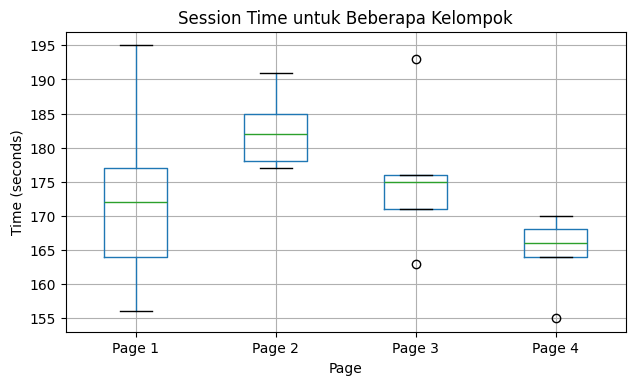

In [11]:
ax = four_sessions.boxplot(column="Time", by="Page", figsize=(7, 4))
ax.set_title("Session Time untuk Beberapa Kelompok")
ax.set_xlabel("Page")
ax.set_ylabel("Time (seconds)")
plt.suptitle("")
plt.show()

In [12]:
groups = [
    group["Time"].to_numpy()
    for _, group in four_sessions.groupby("Page")
]

anova_result = stats.f_oneway(*groups)

print(f"F-statistic : {anova_result.statistic:.4f}")
print(f"p-value     : {anova_result.pvalue:.4f}")

F-statistic : 2.7398
p-value     : 0.0776


### Resampling untuk ANOVA

Selain ANOVA parametrik, ide resampling dapat digunakan untuk membentuk reference distribution secara empiris. Prinsipnya tetap sama: data dikocok sambil mempertahankan ukuran kelompok, kemudian statistik antar-kelompok dihitung berulang kali.

In [13]:
def anova_resampling(df, group_col, value_col, repetitions=5000, seed=42):
    local_rng = np.random.default_rng(seed)

    labels = df[group_col].to_numpy()
    values = df[value_col].to_numpy()

    group_names, counts = np.unique(labels, return_counts=True)
    observed_means = df.groupby(group_col)[value_col].mean().to_numpy()
    observed_stat = np.var(observed_means)

    simulated = np.empty(repetitions)

    for i in range(repetitions):
        shuffled = local_rng.permutation(values)
        start = 0
        means = []

        for count in counts:
            means.append(shuffled[start:start + count].mean())
            start += count

        simulated[i] = np.var(means)

    return observed_stat, simulated


observed_anova, simulated_anova = anova_resampling(
    four_sessions, "Page", "Time", repetitions=5000, seed=42
)

p_anova_resampling = np.mean(simulated_anova >= observed_anova)

print(f"Observed between-group mean variance: {observed_anova:.4f}")
print(f"Resampling p-value: {p_anova_resampling:.4f}")

Observed between-group mean variance: 41.5700
Resampling p-value: 0.0830


## 9. Chi-Square Test

Chi-square test digunakan untuk data berbentuk **count/frequency** dan untuk mengevaluasi apakah pola kategori yang diamati konsisten dengan expectation tertentu.

Dalam konteks contingency table, chi-square statistic mengukur seberapa jauh observed counts menyimpang dari expected counts berdasarkan asumsi independensi.

In [14]:
click_rates = pd.read_csv(DATA_URL + "click_rates.csv")
click_rates

,Headline,Click,Rate
0,Headline A,Click,14
1,Headline A,No-click,986
2,Headline B,Click,8
3,Headline B,No-click,992
4,Headline C,Click,12
5,Headline C,No-click,988


In [15]:
contingency = click_rates.pivot(
    index="Headline",
    columns="Click",
    values="Rate"
)

contingency

Click,Click,No-click
Headline,,
Headline A,14,986
Headline B,8,992
Headline C,12,988


In [16]:
chi2_stat, chi2_p, chi2_df, expected = stats.chi2_contingency(
    contingency,
    correction=False
)

expected_table = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)

print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom  : {chi2_df}")
print(f"p-value              : {chi2_p:.4f}")
print("\nExpected table:")
display(expected_table)

Chi-square statistic: 1.6659
Degrees of freedom  : 2
p-value              : 0.4348

Expected table:


Click,Click,No-click
Headline,,
Headline A,11.3333,988.6667
Headline B,11.3333,988.6667
Headline C,11.3333,988.6667


> **Catatan penting:** pada contoh `click_rates.csv`, data yang tersedia berupa rate. Untuk chi-square klasik, data count/frequency adalah bentuk yang lebih langsung karena expected counts menjadi dasar perhitungan. Notebook ini mempertahankan contoh dataset dan pendekatan pengujian yang digunakan pada bahan kerja.

## 10. Multi-Arm Bandit Algorithm

Buku membahas multi-arm bandit sebagai pendekatan eksperimen yang tidak hanya bertujuan menentukan signifikansi statistik, tetapi juga membantu memilih treatment yang memberikan hasil lebih baik.

Ada dua aktivitas utama:

- **Exploration:** mencoba arm yang belum banyak diketahui;
- **Exploitation:** lebih sering memilih arm yang sementara terlihat memberikan reward lebih tinggi.

Contoh sederhana berikut menggunakan strategi **epsilon-greedy**.

In [17]:
def epsilon_greedy(true_probabilities, rounds=2000, epsilon=0.1, seed=42):
    local_rng = np.random.default_rng(seed)
    n_arms = len(true_probabilities)

    trials = np.zeros(n_arms, dtype=int)
    rewards = np.zeros(n_arms, dtype=int)

    for _ in range(rounds):
        estimated = np.divide(
            rewards,
            trials,
            out=np.zeros(n_arms, dtype=float),
            where=trials > 0
        )

        if local_rng.random() < epsilon:
            arm = local_rng.integers(n_arms)
        else:
            arm = np.argmax(estimated)

        reward = int(local_rng.random() < true_probabilities[arm])

        trials[arm] += 1
        rewards[arm] += reward

    return trials, rewards


true_probabilities = np.array([0.20, 0.04, 0.08])

trials, rewards = epsilon_greedy(
    true_probabilities,
    rounds=2000,
    epsilon=0.10,
    seed=42
)

bandit_result = pd.DataFrame({
    "Arm": ["A", "B", "C"],
    "True probability": true_probabilities,
    "Trials": trials,
    "Observed reward rate": rewards / trials
})

bandit_result

,Arm,True probability,Trials,Observed reward rate
0,A,0.20,1844,0.1979
1,B,0.04,74,0.0541
2,C,0.08,82,0.1098


## 11. Power and Sample Size

**Statistical power** adalah probabilitas untuk mendeteksi efek tertentu ketika efek tersebut memang ada sesuai asumsi yang digunakan.

Sample size, effect size, alpha, dan power saling berhubungan. Secara umum, mendeteksi perbedaan yang sangat kecil membutuhkan lebih banyak observasi dibandingkan mendeteksi perbedaan yang lebih besar.

Contoh berikut menghitung kebutuhan sample size per kelompok untuk perbandingan dua proporsi.

In [18]:
power_analysis = NormalIndPower()

p_control = 0.10
p_treatment = 0.11

effect_small = proportion_effectsize(p_control, p_treatment)

n_small = power_analysis.solve_power(
    effect_size=effect_small,
    alpha=0.05,
    power=0.80,
    alternative="two-sided"
)

print(f"Effect size (10% -> 11%): {effect_small:.4f}")
print(f"Estimated sample size per group: {np.ceil(n_small):.0f}")

Effect size (10% -> 11%): -0.0326
Estimated sample size per group: 14745


In [19]:
p_control = 0.10
p_treatment = 0.15

effect_larger = proportion_effectsize(p_control, p_treatment)

n_larger = power_analysis.solve_power(
    effect_size=effect_larger,
    alpha=0.05,
    power=0.80,
    alternative="two-sided"
)

print(f"Effect size (10% -> 15%): {effect_larger:.4f}")
print(f"Estimated sample size per group: {np.ceil(n_larger):.0f}")

Effect size (10% -> 15%): -0.1519
Estimated sample size per group: 681


## Poin-Poin Penting Bab 3

- A/B testing membandingkan hasil dari dua treatment atau kelompok.
- Hypothesis testing menggunakan null hypothesis, alternative hypothesis, dan test statistic.
- Permutation test membangun reference distribution dengan mengacak kembali data.
- p-value menunjukkan seberapa ekstrem hasil observasi dibandingkan reference distribution di bawah H₀.
- Alpha merupakan significance level yang ditentukan untuk pengujian.
- Type I dan Type II error merupakan dua jenis kesalahan dalam keputusan statistik.
- t-test merupakan pendekatan umum untuk membandingkan rata-rata dua kelompok.
- Multiple testing perlu diperhatikan ketika banyak hipotesis diuji.
- ANOVA digunakan untuk membandingkan lebih dari dua kelompok melalui F-statistic.
- Chi-square test digunakan untuk mengevaluasi penyimpangan count/kategori dari expectation.
- Multi-arm bandit menggabungkan eksplorasi dan eksploitasi dalam eksperimen.
- Power dan sample size membantu merancang eksperimen sebelum data dikumpulkan.

## Referensi Utama

Bruce, P., Bruce, A., & Gedeck, P. *Practical Statistics for Data Scientists*, 2nd ed. O'Reilly Media.

Dataset contoh menggunakan repository data yang disediakan untuk buku tersebut.